In [1]:
!pip install imblearn
!pip install interpret

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE

from interpret.glassbox import ExplainableBoostingClassifier

import shap
import joblib

sns.set_style("whitegrid")

In [2]:
CONFIG = {
    "data_path": "data/parkinsons_clinical.csv",
    "output_dir": "clinical_outputs",
    "test_size": 0.2,
    "random_state": 42
}

os.makedirs(CONFIG["output_dir"], exist_ok=True)

In [3]:
df = pd.read_csv(CONFIG["data_path"])

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (2105, 35)


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,FunctionalAssessment,Tremor,Rigidity,Bradykinesia,PosturalInstability,SpeechProblems,SleepDisorders,Constipation,Diagnosis,DoctorInCharge
0,3058,85,0,3,1,19.619878,0,5.108241,1.380660,3.893969,...,1.572427,1,0,0,0,0,0,0,0,DrXXXConfid
1,3059,75,0,0,2,16.247339,1,6.027648,8.409804,8.513428,...,4.787551,0,1,0,1,0,1,0,1,DrXXXConfid
2,3060,70,1,0,0,15.368239,0,2.242135,0.213275,6.498805,...,2.130686,1,0,0,0,1,0,1,1,DrXXXConfid
3,3061,52,0,0,0,15.454557,0,5.997788,1.375045,6.715033,...,3.391288,1,1,1,0,0,0,1,1,DrXXXConfid
4,3062,87,0,0,1,18.616042,0,9.775243,1.188607,4.657572,...,3.200969,0,0,0,1,0,1,0,0,DrXXXConfid


In [4]:
df = df.drop(columns=["PatientID","DoctorInCharge"], errors="ignore")

df = df.fillna(df.median(numeric_only=True))

In [5]:
# Diagnosis
# 0 → Healthy
# 1 → Parkinson’s

X = df.drop(columns=["Diagnosis"])
y = df["Diagnosis"]

print("Features:", X.shape[1])

Features: 32


In [6]:
categorical_features = [
    "Gender",
    "Ethnicity",
    "EducationLevel",
    "Smoking",
    "FamilyHistoryParkinsons",
    "TraumaticBrainInjury",
    "Hypertension",
    "Diabetes",
    "Depression",
    "Stroke"
]

numeric_features = [
    col for col in X.columns if col not in categorical_features
]

In [7]:
numeric_transformer = Pipeline(
    steps=[("scaler", StandardScaler())]
)

categorical_transformer = Pipeline(
    steps=[("encoder", OneHotEncoder(handle_unknown="ignore"))]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=CONFIG["test_size"],
    stratify=y,
    random_state=CONFIG["random_state"]
)


In [9]:
X_train_proc = preprocessor.fit_transform(X_train)

smote = SMOTE(random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(X_train_proc, y_train)

In [10]:
models = {

    "LogisticRegression":
        LogisticRegression(max_iter=1000),

    "RandomForest":
        RandomForestClassifier(
            n_estimators=300,
            max_depth=8,
            random_state=42
        )
}

In [11]:
cv_results = {}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train_bal,
        y_train_bal,
        scoring="f1",
        cv=cv
    )

    cv_results[name] = scores.mean()

    print(name, "CV F1:", scores.mean())

LogisticRegression CV F1: 0.8311742310153891
RandomForest CV F1: 0.9196562095622657


In [12]:
trained_models = {}

for name, model in models.items():

    model.fit(X_train_bal, y_train_bal)

    trained_models[name] = model

In [13]:
def evaluate_model(model, X_test, y_test, name):

    X_test_proc = preprocessor.transform(X_test)

    preds = model.predict(X_test_proc)
    probs = model.predict_proba(X_test_proc)[:,1]

    acc = accuracy_score(y_test, preds)
    precision = precision_score(y_test, preds)
    recall = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    roc = roc_auc_score(y_test, probs)

    print("\n",name)
    print("Accuracy:", acc)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)
    print("ROC-AUC:", roc)

    print(classification_report(y_test, preds))

    return preds, probs

In [14]:
evaluation = {}

for name, model in trained_models.items():

    preds, probs = evaluate_model(model, X_test, y_test, name)

    evaluation[name] = (preds, probs)


 LogisticRegression
Accuracy: 0.8147268408551069
Precision: 0.8674698795180723
Recall: 0.8275862068965517
F1: 0.8470588235294118
ROC-AUC: 0.9002873563218391
              precision    recall  f1-score   support

           0       0.74      0.79      0.77       160
           1       0.87      0.83      0.85       261

    accuracy                           0.81       421
   macro avg       0.80      0.81      0.81       421
weighted avg       0.82      0.81      0.82       421


 RandomForest
Accuracy: 0.9049881235154394
Precision: 0.9233716475095786
Recall: 0.9233716475095786
F1: 0.9233716475095786
ROC-AUC: 0.9614463601532567
              precision    recall  f1-score   support

           0       0.88      0.88      0.88       160
           1       0.92      0.92      0.92       261

    accuracy                           0.90       421
   macro avg       0.90      0.90      0.90       421
weighted avg       0.90      0.90      0.90       421



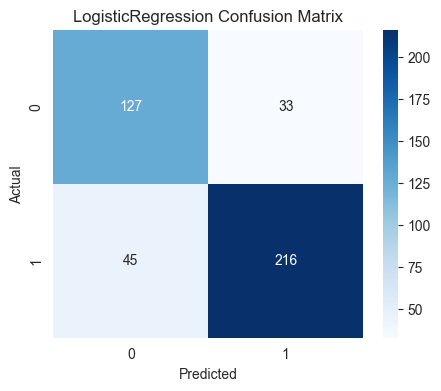

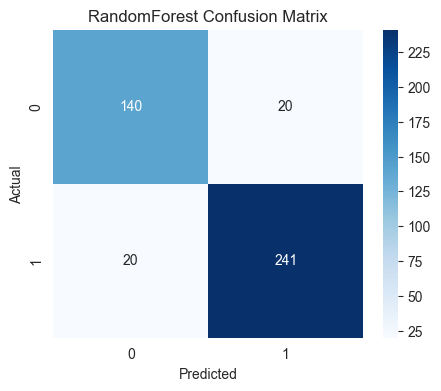

In [15]:
for name, (preds, probs) in evaluation.items():

    cm = confusion_matrix(y_test, preds)

    plt.figure(figsize=(5,4))

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

    plt.title(f"{name} Confusion Matrix")

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.savefig(f"{CONFIG['output_dir']}/{name}_confusion_matrix.png")

    plt.show()

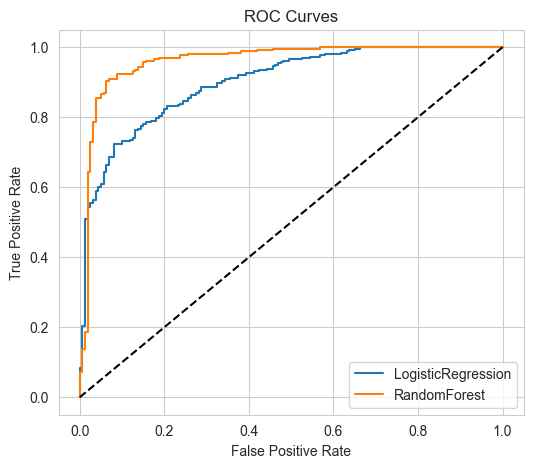

In [16]:
plt.figure(figsize=(6,5))

for name, (preds, probs) in evaluation.items():

    fpr, tpr, _ = roc_curve(y_test, probs)

    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curves")

plt.legend()

plt.savefig(f"{CONFIG['output_dir']}/roc_curves.png")

plt.show()

In [17]:
best_model_name = max(cv_results, key=cv_results.get)

best_model = trained_models[best_model_name]

print("Best Model:", best_model_name)

Best Model: RandomForest


 96%|=================== | 383/400 [00:27<00:01]       

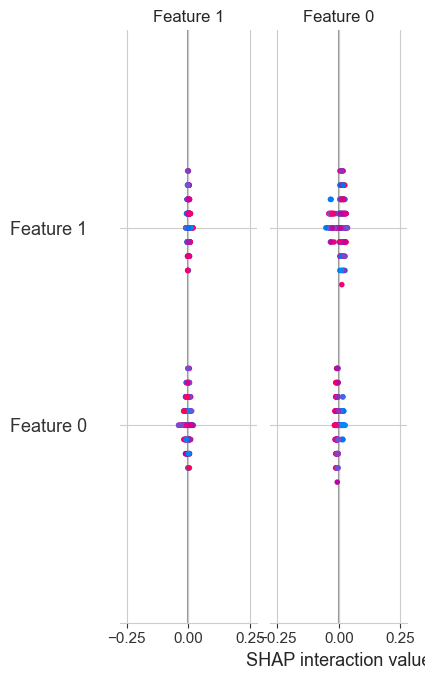

In [18]:
explainer = shap.Explainer(best_model, X_train_bal)

shap_values = explainer(X_train_bal[:200])

shap.summary_plot(shap_values, show=False)

plt.savefig(f"{CONFIG['output_dir']}/shap_summary.png")

plt.show()

In [19]:
joblib.dump(best_model,
            f"{CONFIG['output_dir']}/clinical_model.pkl")

joblib.dump(preprocessor,
            f"{CONFIG['output_dir']}/preprocessing_pipeline.pkl")

print("Clinical model saved")

Clinical model saved
